# Phidl experiments
----------

In [2]:
import gdspy

from phidl import Device
import phidl.geometry as pg
from phidl import quickplot as qp
from phidl import set_quickplot_options as set_qp_options

import numpy as np

## 1. Quick plotting

In [3]:
import matplotlib
matplotlib.use("QtAgg")

In [4]:
print(matplotlib.get_backend())

QtAgg


In [5]:
# --- make a simple device ---
D = Device("demo")

rect = pg.rectangle(size=(20, 10), layer=(1, 0))
D.add_ref(rect)

# optional: add ports so you can see them
D.add_port(
    name="p1",
    midpoint=(0, 5),
    width=10,
    orientation=180,
)

# --- configure quickplot behavior ---
set_qp_options(
    new_window=True,     # open a new window
    blocking=True,      # don't halt script execution
    show_ports=True,     # draw ports
    show_subports=True, # don't show ports of references
)

# --- show it ---
qp(D)

## 2. Test device/cell hierarchy

In [6]:
%matplotlib inline

In [7]:
print(matplotlib.get_backend())

module://matplotlib_inline.backend_inline


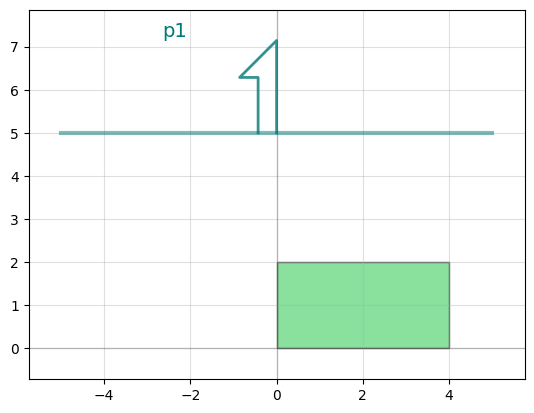

In [20]:
Top_Device = Device('TOP')

Sub_Device = Device('Sub device')

rectangle_ref = Sub_Device << pg.rectangle()

Sub_Device.add_port(
    name="p1",
    midpoint=(0, 5),
    width=10,
    orientation=90,
)

Top_Device << Sub_Device

qp(Top_Device)

In [9]:
Top_Device.write_gds('Test_Hierarchy.gds')

'Test_Hierarchy.gds'

In [10]:
import gdspy
from collections import Counter

In [11]:
def inspect_gds_hierarchy(gds_path):
    lib = gdspy.GdsLibrary(infile=gds_path)

    tops = lib.top_level()
    print("Top-level cells:", [c.name for c in tops])
    top = tops[0]  # pick the first top cell (change if needed)

    # --- build direct reference map: cell -> Counter(referenced_cell -> count) ---
    edges = {}
    for name, cell in lib.cells.items():
        ctr = Counter()
        for ref in (cell.references or []):
            tgt = getattr(ref, "ref_cell", None)
            if tgt is not None:
                ctr[tgt.name] += 1
        edges[name] = ctr

    print("\nHierarchy:")
    print_tree(top.name, edges)

# --- pretty-print hierarchy tree ---
def print_tree(name, edges, prefix="", stack=None):
    if stack is None:
        stack = set()
    if name in stack:
        print(prefix + name + "  (cycle)")
        return

    print(prefix + name)
    stack.add(name)

    kids = edges.get(name, Counter())
    items = sorted(kids.items(), key=lambda kv: (-kv[1], kv[0]))

    for i, (kid, n) in enumerate(items):
        last = (i == len(items) - 1)
        branch = "└── " if last else "├── "
        next_prefix = prefix + ("    " if last else "│   ")
        print(prefix + branch + f"{kid}  x{n}")
        print_tree(
            kid,
            edges,
            prefix=next_prefix,
            stack=stack
        )

    stack.remove(name)

In [12]:
# --- load GDS ---
gds_path = "Test_Hierarchy.gds"

inspect_gds_hierarchy(gds_path)

Top-level cells: ['toplevel']

Hierarchy:
toplevel
└── Sub device  x1
    Sub device
    └── rectangle  x1
        rectangle


## 3. Compass

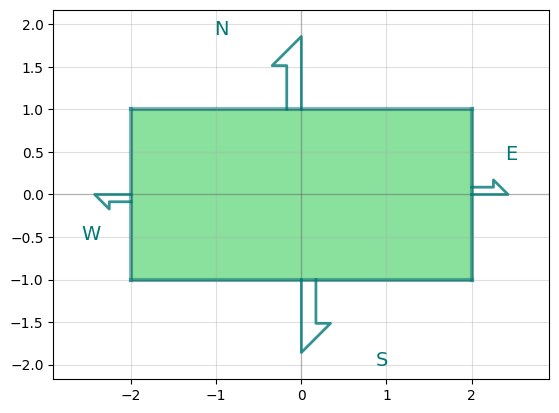

In [14]:
Compass_Device = Device('Compass')

Compass_Device << pg.compass()
qp(Compass_Device)

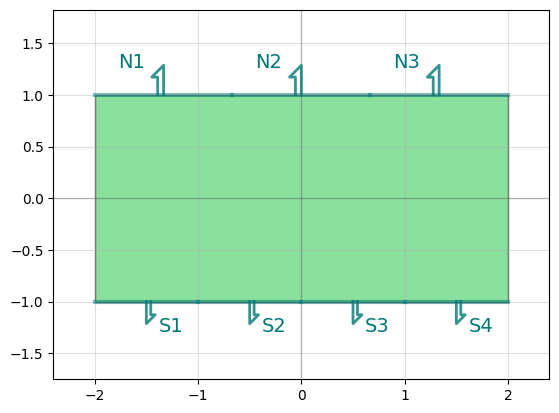

In [16]:
Multi_Compass_Device = Device('Compass')

Multi_Compass_Device << pg.compass_multi()
qp(Multi_Compass_Device)

## 4. Single Pass Lines/Zero Width Path

c:\Users\aw270929\Miniconda3\envs\phidl\lib\site-packages\gdspy\path.py:662: RuntimeWarning: invalid value encountered in double_scalars
  u0 = (v1[1] * dx - v1[0] * dy) / den
c:\Users\aw270929\Miniconda3\envs\phidl\lib\site-packages\gdspy\path.py:663: RuntimeWarning: invalid value encountered in double_scalars
  u1 = (v0[1] * dx - v0[0] * dy) / den


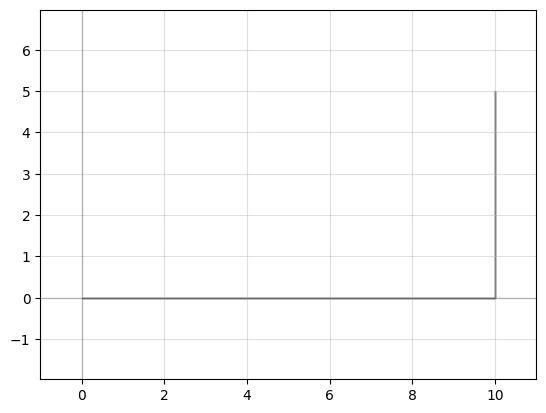

'phidl_with_flexpath.gds'

In [17]:
# --- Build PHIDL device (PHIDL Devices behave like gdspy Cells for storage/export)
D = Device("MY_DEVICE")

# --- Make a FlexPath (width=0 for centerline)
# gdsii_path=True encourages writing as a true GDSII PATH when possible
fp = gdspy.FlexPath(
    [(0, 0), (10, 0), (10, 5)],   # spine points
    width=0,                      # zero-width centerline
    layer=1,
    datatype=0,
    ends="flush",
    gdsii_path=True
)

# --- Add the gdspy FlexPath into the PHIDL Device
# This uses the underlying gdspy Cell storage convention (Cell.paths list). :contentReference[oaicite:3]{index=3}
D.add(fp)

qp(D)

# --- Write to GDS using PHIDL (creates a library and serializes)
# cellname controls the top-level cell name PHIDL uses when writing. :contentReference[oaicite:4]{index=4}
out = "phidl_with_flexpath.gds"
D.write_gds(out, cellname="TOP")



In [18]:
# --- Verify by re-loading with gdspy and counting paths
lib = gdspy.GdsLibrary(infile=out)

total_paths = sum(len(cell.paths) for cell in lib.cells.values())
print("Cells in file:", list(lib.cells.keys()))
print("Total paths in file:", total_paths)

# Optional: print per-cell path counts
for name, cell in lib.cells.items():
    if len(cell.paths):
        print(f"{name}: paths={len(cell.paths)}")

Cells in file: ['TOP']
Total paths in file: 1
TOP: paths=1
